In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:

from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [59]:
class Value:
    
    def __init__(self, data, _children = (), _op = "", label = ""): # "_" ile başlayan değişkenler classın içinde dönen değerler demek
        
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None # Boş bir fonksiyon oluştur
        self._prev = set(_children) # tuple'ın içinde tekrar eden değerleri siliyor
        self._op = _op 
        self.label = label
        
    def __repr__(self): # Python use __repr__ function to return
        return f"Value(data={self.data})"
    
    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data , (self,other),"+")
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __mul__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data , (self,other),"*")
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out
    
    def __pow__(self,other):
        assert isinstance(other,(int,float))
        out = Value(self.data ** other, (self,), f'**{other}')
        
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward    
        
        return out
    
    def __truediv__(self, other):
        return self * other**-1
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self,other):
        return self + (-other)
    
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t,(self,),"tanh")
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), "exp")
        
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        
        return out 
    
    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

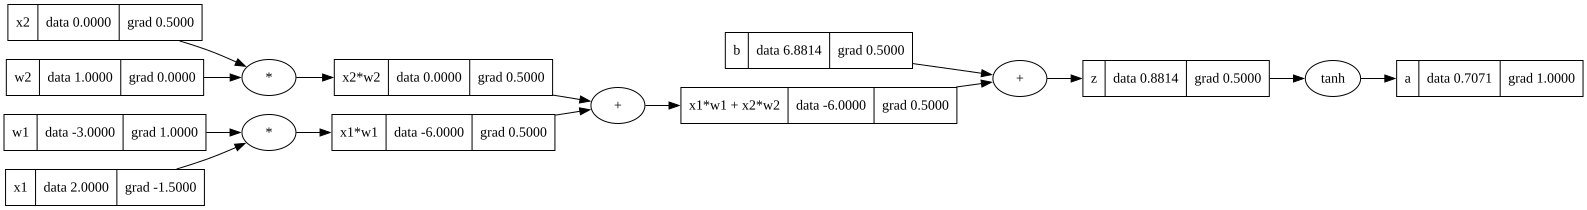

In [49]:

x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2") 

w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

b = Value(6.8813735870195432, label="b")

x1w1 = x1*w1; x1w1.label = "x1*w1"
x2w2 = x2*w2; x2w2.label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1*w1 + x2*w2"
z = x1w1x2w2 + b; z.label = "z"
a = z.tanh(); a.label = "a"

a.backward()
draw_dot(a)

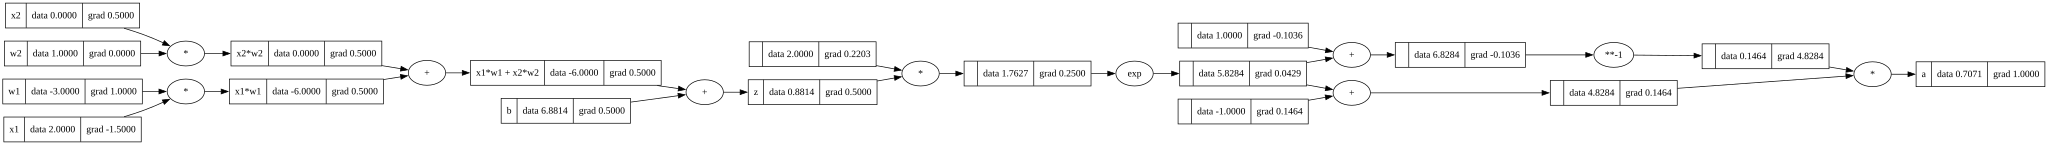

In [60]:
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2") 

w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

b = Value(6.8813735870195432, label="b")

x1w1 = x1*w1; x1w1.label = "x1*w1"
x2w2 = x2*w2; x2w2.label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1*w1 + x2*w2"
z = x1w1x2w2 + b; z.label = "z"

e = (z*2).exp()
a = (e - 1) / (e + 1)
a.label = "a"

a.backward()
draw_dot(a)

In [35]:
a._backward()

In [36]:
x1w1._backward()

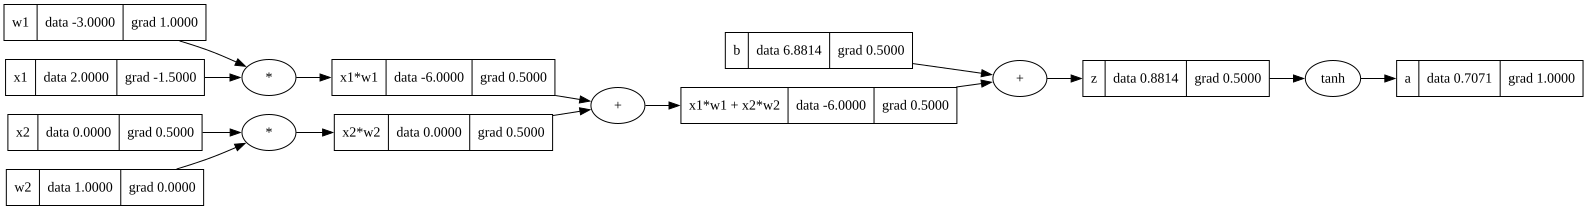

In [ ]:
a.grad = 1
z.grad = (1 - a.data**2) * a.grad
b.grad = z.grad * 1.0
x1w1x2w2.grad = z.grad * 1.0

x1w1.grad = x1w1x2w2.grad * 1.0
x2w2.grad = x1w1x2w2.grad * 1.0

w1.grad = x1.data * x1w1.grad
x1.grad = w1.data * x1w1.grad

w2.grad = x2w2.grad * x2.data
x2.grad = x2w2.grad * w2.data

draw_dot(a)


In [5]:
L.grad = 1.0
d.grad = -2.0 * L.grad
f.grad = 4.0 * L.grad
e.grad = 1.0 * d.grad 
c.grad = 1.0 * d.grad 
a.grad = -3.0 * e.grad
b.grad = 2.0 * e.grad



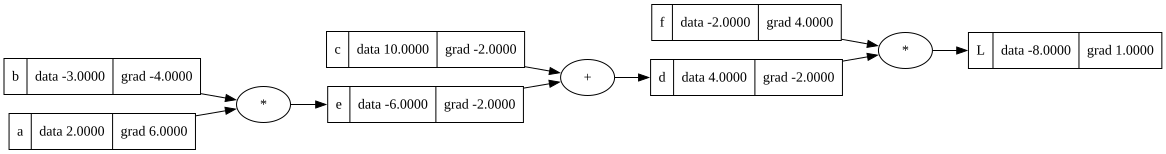

In [6]:
draw_dot(L)

In [4]:
a = Value(2.0,label="a")
b = Value(-3.0,label="b")
c = Value(10.0,label="c")
e = a*b; e.label = "e"
d = e + c; d.label = "d"
f = Value(-2.0, label="f")
L = d * f; L.label = "L"
L

Value(data=-8.0)